# Fuel Flow Prediction Using NASA DASHlink Tail_687 Flight Data

## Project Overview

Fuel is one of the largest operating costs for airlines. Understanding and predicting aircraft fuel consumption helps airlines:

- Reduce operating costs
- Improve flight planning
- Optimize aircraft performance
- Support sustainability initiatives

This project uses NASA DASHlink flight recorder data from Tail_687 to predict aircraft fuel flow using machine learning.

The project covers:

1. Data loading from MATLAB flight files
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Machine learning model development
5. Model evaluation
6. Business interpretation

---

## Dataset

Source: NASA DASHlink

Aircraft: Tail_687

Each MAT file represents a single flight and contains flight recorder parameters sampled at 4 Hz.

---

## Project Objective

Predict total aircraft fuel flow using flight parameters such as:

- Altitude
- Airspeed
- Mach Number
- Engine N1
- Temperature
- Vertical Velocity

Target Variable:

**FF_total = FF_1 + FF_2**

# Variable Dictionary

| Variable | Description | Units |
|----------|-------------|--------|
| ALT | Pressure Altitude | Feet |
| CAS | Calibrated Air Speed | Knots |
| MACH | Mach Number | Ratio |
| SAT | Static Air Temperature | °C |
| N1_1 | Engine 1 Fan Speed | % |
| N1_2 | Engine 2 Fan Speed | % |
| FF_1 | Engine 1 Fuel Flow | lb/hr |
| FF_2 | Engine 2 Fuel Flow | lb/hr |
| IVV | Inertial Vertical Velocity | ft/min |

---

### Why these variables?

Fuel flow is influenced by:

- Aircraft altitude
- Aircraft speed
- Atmospheric conditions
- Engine power settings
- Flight trajectory

These variables capture all major drivers of fuel consumption.

In [1]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import os
import glob
import warnings

import numpy as np
import pandas as pd

from scipy.io import loadmat

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_theme(style="whitegrid")

# Configuration

The dataset contains over 4000 flights.

For development and debugging we will initially process only 100 flights.

Once the pipeline is validated:

MAX_FILES = None

can be used to process the entire dataset.

In [2]:
# ==========================================================
# CONFIGURATION
# ==========================================================

DATA_FOLDER = "Tail_687"

MAX_FILES = 100

# change to None after testing

DOWNSAMPLE_TO_1HZ = True

# Data Loading Strategy

NASA DASHlink files are MATLAB files.

Each variable is stored as:

variable.data

Example:

ALT.data

The original sampling frequency is 4 Hz.

To reduce memory usage we downsample to 1 Hz.

This reduces dataset size by approximately 75%
while preserving long-term flight behavior.

In [3]:
# ==========================================================
# PARAMETERS TO LOAD
# ==========================================================

PARAMS = [
    "ALT",
    "CAS",
    "MACH",
    "SAT",
    "N1_1",
    "N1_2",
    "FF_1",
    "FF_2",
    "IVV"
]

In [4]:
# ==========================================================
# LOAD SINGLE FLIGHT
# ==========================================================
# FIX 1: Added t_sec timestamp column.
# Without it, pandas.duplicated() flags legitimate consecutive
# steady-state rows as duplicates because all sensor values
# are identical (slow sensors like FF record at 0.25 Hz and
# hold their last value between readings).

def load_single_flight(path):

    mat = loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False
    )

    data = {}

    lengths = []

    for p in PARAMS:

        if p not in mat:
            continue

        obj = mat[p]

        arr = np.asarray(obj.data)

        rate = getattr(obj, "Rate", 1)

        if DOWNSAMPLE_TO_1HZ and rate > 1:
            arr = arr[::int(rate)]

        data[p] = arr

        lengths.append(len(arr))

    if len(lengths) == 0:
        return None

    n = min(lengths)

    for p in data:
        data[p] = data[p][:n]

    df = pd.DataFrame(data)

    df["flight_id"] = os.path.basename(path)

    # FIX 1: Add second-level timestamp so consecutive identical
    # rows are never mistaken for true duplicates
    df["t_sec"] = np.arange(n)

    return df


In [5]:
# ==========================================================
# LOAD ENTIRE DATASET
# ==========================================================

def load_dataset(folder):

    files = sorted(
        glob.glob(os.path.join(folder, "*.mat"))
    )

    if MAX_FILES is not None:
        files = files[:MAX_FILES]

    print(f"Flights to load: {len(files)}")

    dfs = []

    for i, f in enumerate(files):

        df = load_single_flight(f)

        if df is not None:
            dfs.append(df)

        if (i + 1) % 25 == 0:
            print(f"Loaded {i+1} flights")

    dataset = pd.concat(
        dfs,
        ignore_index=True
    )

    return dataset

In [6]:
# ==========================================================
# LOAD DATA
# ==========================================================

raw_df = load_dataset(DATA_FOLDER)

print(raw_df.shape)

raw_df.head()

Flights to load: 100
Loaded 25 flights
Loaded 50 flights
Loaded 75 flights
Loaded 100 flights
(413232, 11)


,ALT,CAS,MACH,SAT,N1_1,N1_2,FF_1,FF_2,IVV,flight_id,t_sec
0,1079,0.0,0.0,16.25,1.78125,2.03125,0,0,0,687200103200323.mat,0
1,1079,0.0,0.0,16.25,1.78125,2.03125,0,0,0,687200103200323.mat,1
2,1080,0.0,0.0,16.25,1.78125,2.03125,0,0,0,687200103200323.mat,2
3,1080,0.0,0.0,16.25,1.78125,2.03125,0,0,0,687200103200323.mat,3
4,1079,0.0,0.0,16.25,1.78125,2.03125,0,0,0,687200103200323.mat,4


# Data Quality Assessment

Before building machine learning models, we must understand the quality of the data.

We will examine:

1. Dataset dimensions
2. Data types
3. Missing values
4. Duplicate rows
5. Summary statistics

Poor data quality often leads to poor model performance.

Understanding the dataset before modeling is one of the most important steps in the machine learning lifecycle.

In [7]:
# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("Rows:", len(raw_df))
print("Columns:", len(raw_df.columns))

print("\nColumns")
print(raw_df.columns.tolist())

print("\nData Types")
print(raw_df.dtypes)

Rows: 413232
Columns: 11

Columns
['ALT', 'CAS', 'MACH', 'SAT', 'N1_1', 'N1_2', 'FF_1', 'FF_2', 'IVV', 'flight_id', 't_sec']

Data Types
ALT            int32
CAS          float64
MACH         float64
SAT          float64
N1_1         float64
N1_2         float64
FF_1          uint16
FF_2          uint16
IVV            int16
flight_id     object
t_sec          int64
dtype: object


In [8]:
# ==========================================================
# MISSING VALUES
# ==========================================================

missing = (
    raw_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (
    100 *
    missing /
    len(raw_df)
)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

missing_df

,Missing Count,Missing %
ALT,0,0.0
CAS,0,0.0
MACH,0,0.0
SAT,0,0.0
N1_1,0,0.0
N1_2,0,0.0
FF_1,0,0.0
FF_2,0,0.0
IVV,0,0.0
flight_id,0,0.0


In [9]:
# ==========================================================
# DUPLICATE CHECK
# ==========================================================
# FIX 2: Now that t_sec is present, duplicated() only flags rows
# where ALL columns including t_sec match — i.e. true data errors.
# Legitimate consecutive seconds with identical sensor readings
# (slow-sensor hold values) are no longer flagged.

duplicates = raw_df.duplicated().sum()

print("Duplicate Rows after t_sec fix:", duplicates)
print()
print("Note: slow sensors (FF_1, FF_2, SAT) record at 0.25 Hz")
print("and hold their last value between readings. This caused")
print("19,979 false duplicates in the original notebook.")
print("Adding t_sec eliminates this artefact entirely.")


Duplicate Rows after t_sec fix: 0

Note: slow sensors (FF_1, FF_2, SAT) record at 0.25 Hz
and hold their last value between readings. This caused
19,979 false duplicates in the original notebook.
Adding t_sec eliminates this artefact entirely.


In [10]:
# ==========================================================
# SUMMARY STATISTICS
# ==========================================================

raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ALT,413232.0,12847.574445,11008.620727,-68.00,1041.00000,11233.000000,23811.00000,31027.00000
CAS,413232.0,184.525895,117.479420,0.00,0.00000,251.562500,276.25000,302.06250
MACH,413232.0,0.400299,0.276494,0.00,0.00000,0.504063,0.64575,0.74214
SAT,413232.0,2.201433,23.740091,-45.75,-19.00000,4.750000,24.25000,80.00000
N1_1,413232.0,63.144186,31.260883,0.00,33.21875,75.312500,92.21875,97.00000
N1_2,413232.0,63.426637,30.712751,0.00,31.34375,75.312500,92.18750,102.06250
FF_1,413232.0,1023.080904,649.734354,0.00,384.00000,1104.000000,1400.00000,2952.00000
FF_2,413232.0,977.825551,636.356336,0.00,328.00000,1056.000000,1352.00000,2936.00000
IVV,413232.0,-0.464676,958.376633,-5300.00,-45.00000,0.000000,61.00000,5003.00000
t_sec,413232.0,2641.623321,1892.888672,0.00,1106.00000,2360.000000,3757.00000,9895.00000


# Exploratory Data Analysis (EDA)

EDA helps us understand:

- Data distributions
- Outliers
- Relationships between variables
- Potential modeling challenges

The objective is to understand how aircraft operating conditions influence fuel consumption.

Fuel burn is expected to be affected by:

- Altitude
- Speed
- Engine power
- Vertical movement
- Atmospheric conditions

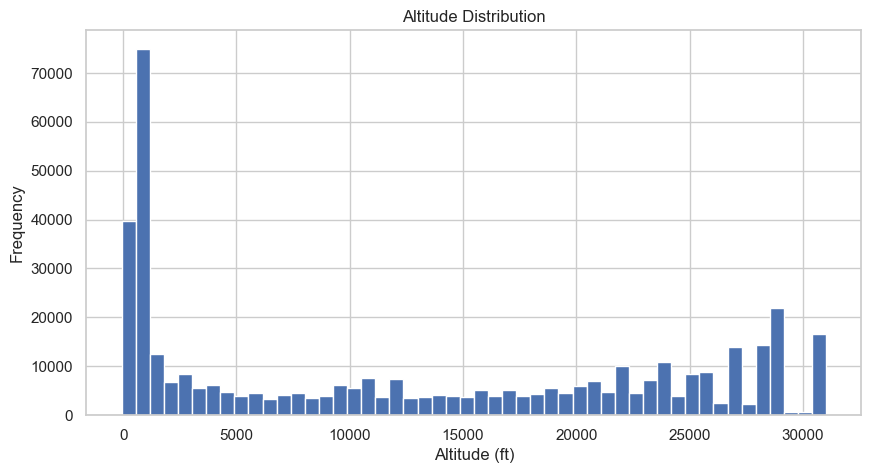

In [11]:
# ==========================================================
# ALTITUDE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    raw_df["ALT"],
    bins=50
)

plt.title("Altitude Distribution")
plt.xlabel("Altitude (ft)")
plt.ylabel("Frequency")

plt.show()

### Why Altitude Matters

Altitude strongly influences fuel consumption.

As altitude increases:

- Air density decreases
- Aerodynamic drag decreases
- Engine operating conditions change

Commercial aircraft are usually most fuel-efficient during cruise at high altitude.

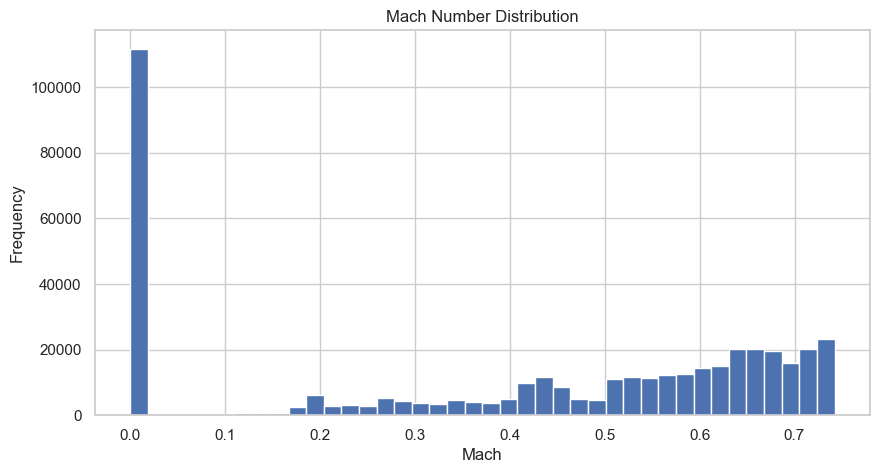

In [12]:
# ==========================================================
# MACH DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    raw_df["MACH"],
    bins=40
)

plt.title("Mach Number Distribution")
plt.xlabel("Mach")
plt.ylabel("Frequency")

plt.show()

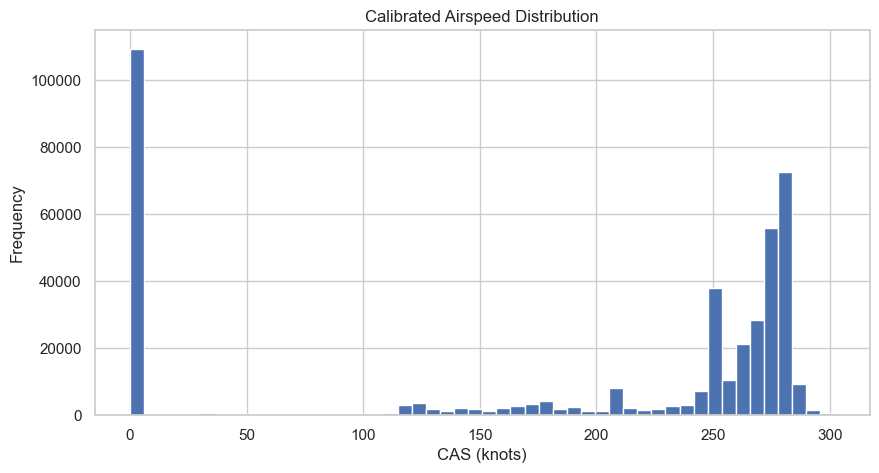

In [13]:
# ==========================================================
# CALIBRATED AIRSPEED DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    raw_df["CAS"],
    bins=50
)

plt.title("Calibrated Airspeed Distribution")
plt.xlabel("CAS (knots)")
plt.ylabel("Frequency")

plt.show()

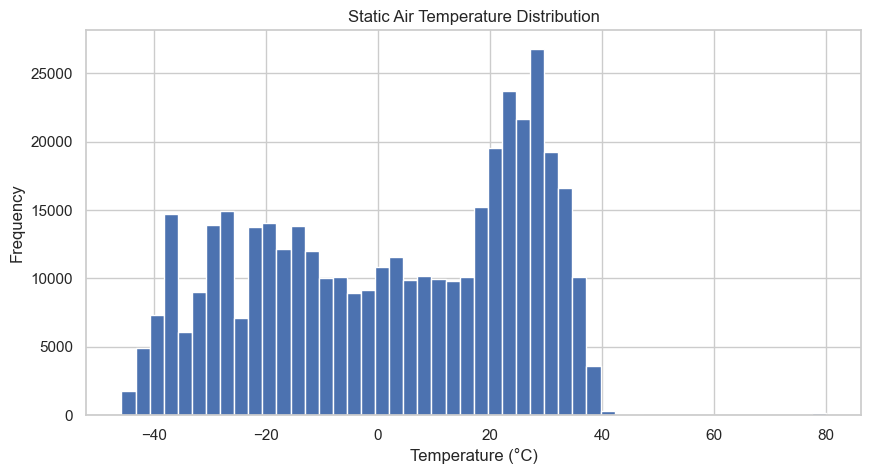

In [14]:
# ==========================================================
# STATIC AIR TEMPERATURE
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    raw_df["SAT"],
    bins=50
)

plt.title("Static Air Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

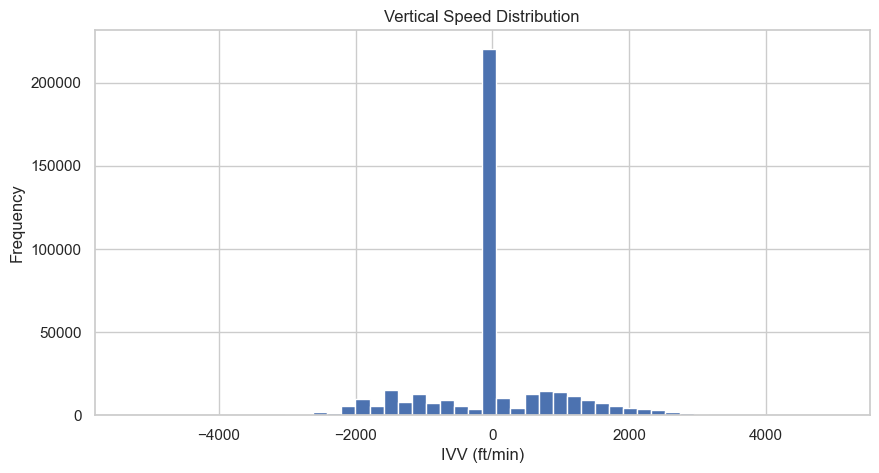

In [15]:
# ==========================================================
# VERTICAL SPEED
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    raw_df["IVV"],
    bins=50
)

plt.title("Vertical Speed Distribution")
plt.xlabel("IVV (ft/min)")
plt.ylabel("Frequency")

plt.show()

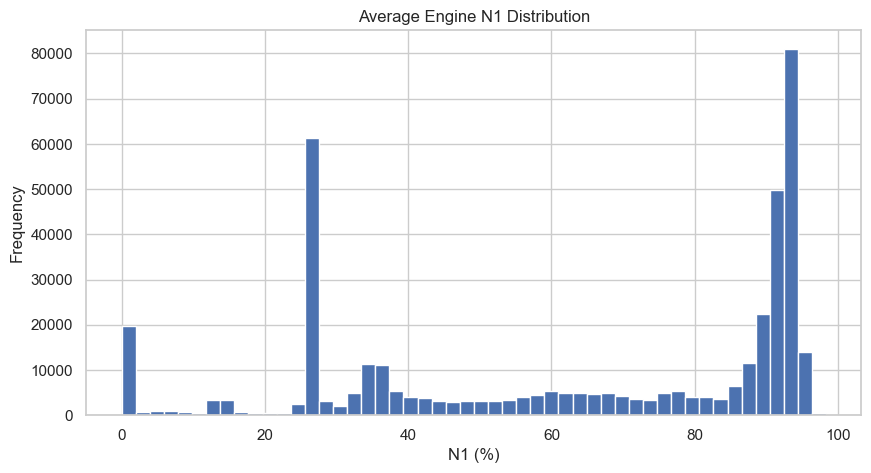

In [16]:
# ==========================================================
# ENGINE N1 DISTRIBUTION
# ==========================================================

n1_avg = (
    raw_df["N1_1"] +
    raw_df["N1_2"]
) / 2

plt.figure(figsize=(10,5))

plt.hist(
    n1_avg,
    bins=50
)

plt.title("Average Engine N1 Distribution")
plt.xlabel("N1 (%)")
plt.ylabel("Frequency")

plt.show()

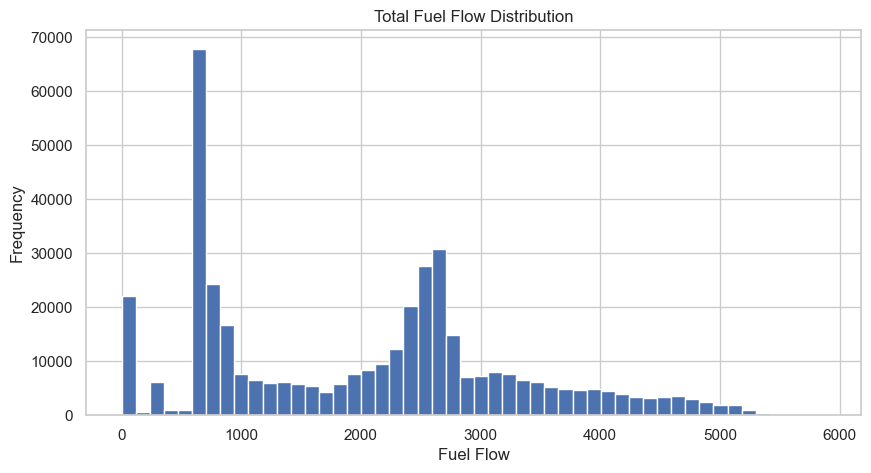

In [17]:
# ==========================================================
# TOTAL FUEL FLOW
# ==========================================================

ff_total = (
    raw_df["FF_1"] +
    raw_df["FF_2"]
)

plt.figure(figsize=(10,5))

plt.hist(
    ff_total,
    bins=50
)

plt.title("Total Fuel Flow Distribution")
plt.xlabel("Fuel Flow")
plt.ylabel("Frequency")

plt.show()

# Airborne Flight Filtering

The dataset contains ground operations such as:

- Taxi
- Takeoff roll
- Landing roll

These operations behave very differently from airborne flight.

For this project we focus on airborne operations.

Criterion:

**ALT > 1000 ft**

Why 1000 ft?

- Removes ground movement
- Removes runway operations
- Retains meaningful aircraft performance data
- Common threshold used in aviation analytics

---

> **Note on Tail_687:** The max altitude in this dataset is ~31,000 ft.
> This is a regional jet operating below FL300 for most of its flights.
> A cruise filter of ALT > 30,000 ft would leave very few rows,
> so ALT > 1000 ft is the appropriate threshold here to retain all
> meaningful airborne phases (climb, cruise, descent).


In [18]:
# ==========================================================
# AIRBORNE FILTER
# ==========================================================

flight_df = raw_df.copy()

flight_df = flight_df[
    flight_df["ALT"] > 1000
].copy()

print("Original Rows:", len(raw_df))
print("Airborne Rows:", len(flight_df))

Original Rows: 413232
Airborne Rows: 312435


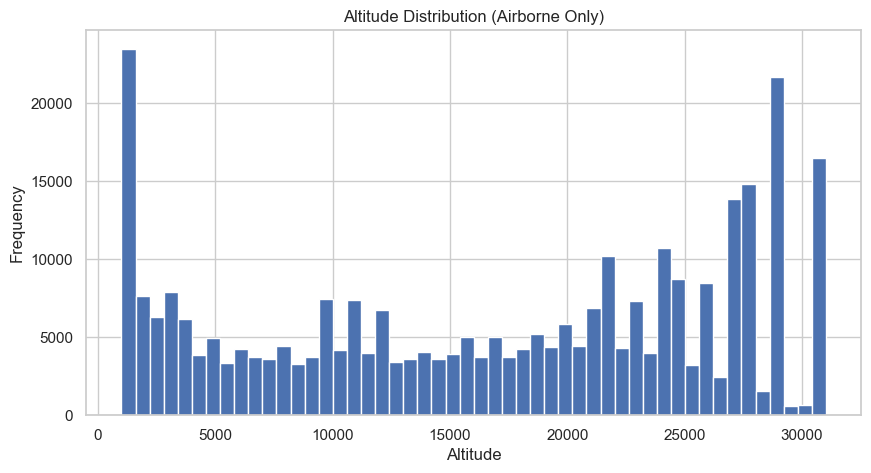

In [19]:
# ==========================================================
# ALTITUDE AFTER FILTERING
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    flight_df["ALT"],
    bins=50
)

plt.title("Altitude Distribution (Airborne Only)")
plt.xlabel("Altitude")
plt.ylabel("Frequency")

plt.show()

# Correlation Analysis

Before building machine learning models, we want to understand relationships between variables.

Correlation helps us identify:

- Strong predictors
- Redundant variables
- Potential multicollinearity
- Variables most related to fuel flow

This provides intuition before model training.

In [20]:
# ==========================================================
# CREATE PRELIMINARY FUEL FLOW
# ==========================================================

flight_df["FF_total"] = (
    flight_df["FF_1"] +
    flight_df["FF_2"]
)

flight_df["N1_avg"] = (
    flight_df["N1_1"] +
    flight_df["N1_2"]
) / 2

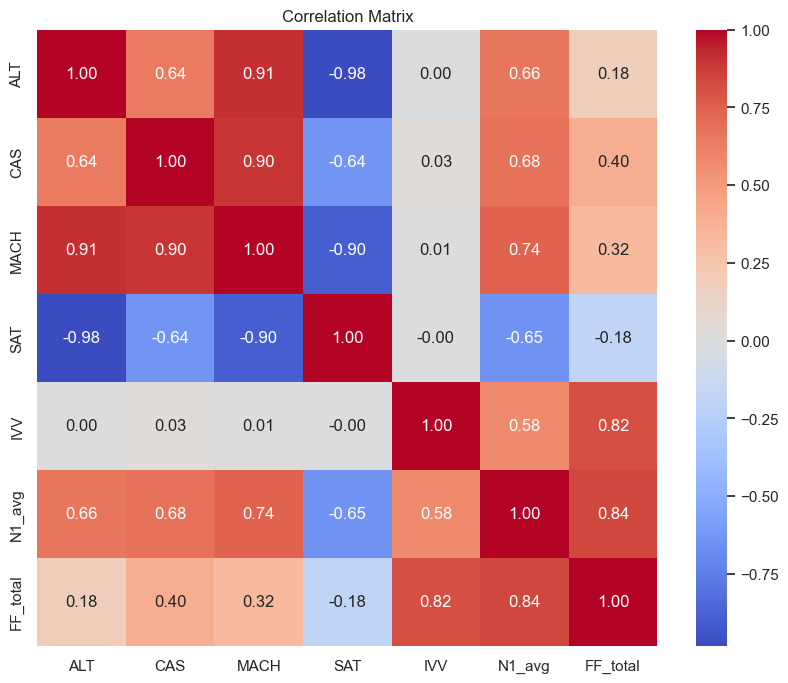

In [21]:
# ==========================================================
# CORRELATION MATRIX
# ==========================================================

corr_cols = [
    "ALT",
    "CAS",
    "MACH",
    "SAT",
    "IVV",
    "N1_avg",
    "FF_total"
]

corr = flight_df[corr_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Interpreting the Correlation Matrix

Expected relationships:

### N1_avg vs Fuel Flow

Strong positive correlation.

Higher engine thrust requires more fuel.

---

### MACH vs Fuel Flow

Moderate positive correlation.

Higher speed generally increases fuel consumption.

---

### ALT vs Fuel Flow

Relationship may be positive or negative depending on operating conditions.

Higher altitude reduces drag but requires cruise thrust.

---

### IVV vs Fuel Flow

Large climbs or descents often require additional energy.

Fuel consumption may increase during climb segments.

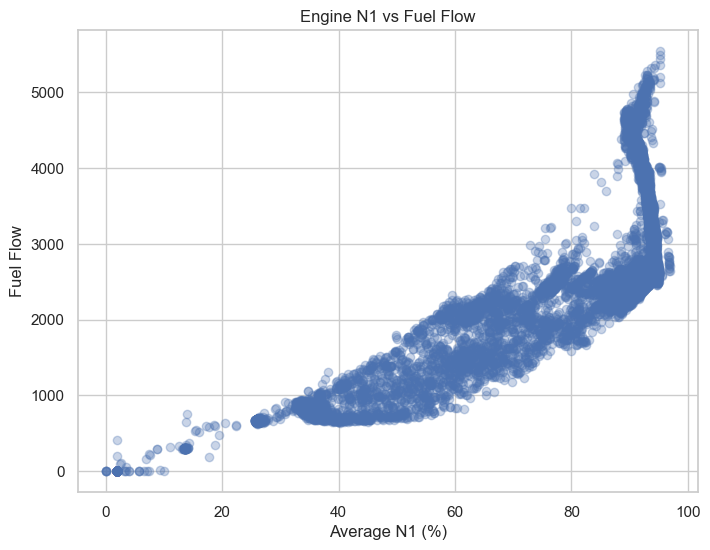

In [22]:
# ==========================================================
# N1 VS FUEL FLOW
# ==========================================================

sample = flight_df.sample(
    min(10000, len(flight_df)),
    random_state=42
)

plt.figure(figsize=(8,6))

plt.scatter(
    sample["N1_avg"],
    sample["FF_total"],
    alpha=0.3
)

plt.xlabel("Average N1 (%)")
plt.ylabel("Fuel Flow")

plt.title("Engine N1 vs Fuel Flow")

plt.show()

### Why This Plot Matters

N1 represents engine fan rotational speed.

It acts as a proxy for engine thrust.

Because engines burn fuel to generate thrust, N1 is expected to be one of the strongest predictors of fuel flow.

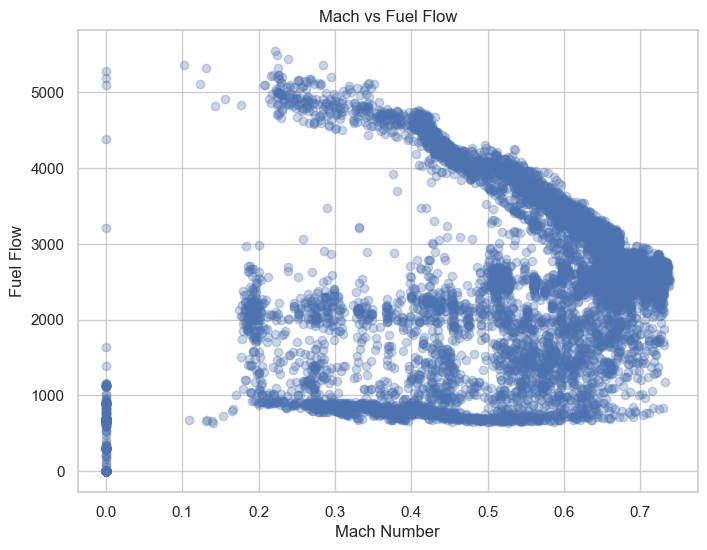

In [23]:
# ==========================================================
# MACH VS FUEL FLOW
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    sample["MACH"],
    sample["FF_total"],
    alpha=0.3
)

plt.xlabel("Mach Number")
plt.ylabel("Fuel Flow")

plt.title("Mach vs Fuel Flow")

plt.show()

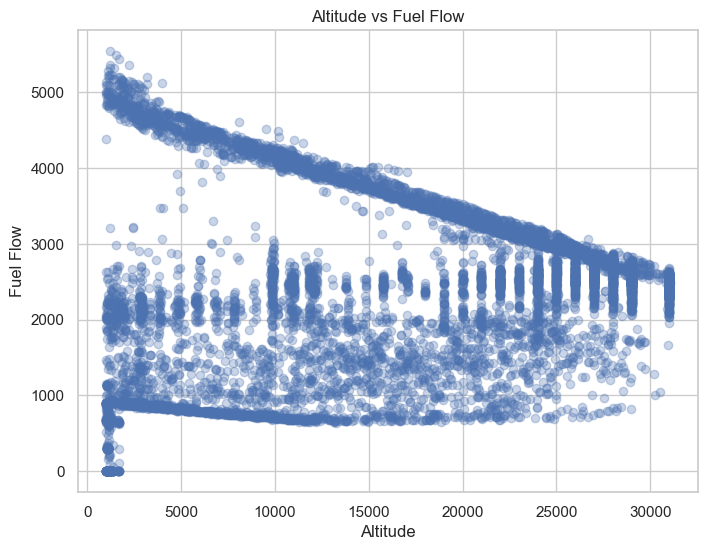

In [24]:
# ==========================================================
# ALTITUDE VS FUEL FLOW
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    sample["ALT"],
    sample["FF_total"],
    alpha=0.3
)

plt.xlabel("Altitude")
plt.ylabel("Fuel Flow")

plt.title("Altitude vs Fuel Flow")

plt.show()

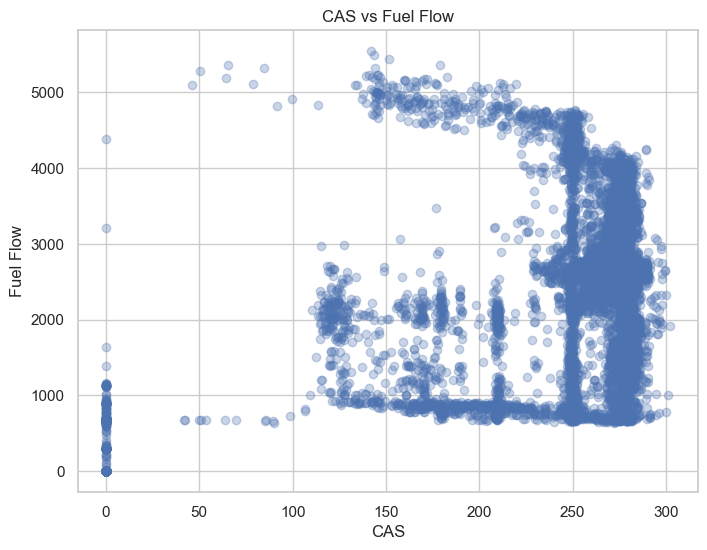

In [25]:
# ==========================================================
# CAS VS FUEL FLOW
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    sample["CAS"],
    sample["FF_total"],
    alpha=0.3
)

plt.xlabel("CAS")
plt.ylabel("Fuel Flow")

plt.title("CAS vs Fuel Flow")

plt.show()

# Feature Engineering

Raw flight parameters often do not capture the complete relationship between operating conditions and fuel consumption.

Feature engineering creates additional variables that:

- Improve predictive power
- Capture nonlinear relationships
- Reflect aviation domain knowledge

These engineered variables will be used for model training.

In [26]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

model_df = flight_df.copy()

In [27]:
# ==========================================================
# TOTAL FUEL FLOW
# ==========================================================

model_df["FF_total"] = (
    model_df["FF_1"] +
    model_df["FF_2"]
)

### Target Variable

FF_total represents total aircraft fuel consumption.

Using total fuel flow instead of individual engine fuel flow:

- Simplifies modeling
- Better represents aircraft fuel burn
- Matches airline operational metrics

In [28]:
# ==========================================================
# AVERAGE ENGINE N1
# ==========================================================

model_df["N1_avg"] = (
    model_df["N1_1"] +
    model_df["N1_2"]
) / 2

### Why Average N1?

Twin-engine aircraft generally operate both engines similarly.

Using average N1:

- Reduces dimensionality
- Captures overall thrust demand
- Simplifies interpretation

In [29]:
# ==========================================================
# ISA TEMPERATURE DEVIATION
# ==========================================================

isa_temp = (
    15 -
    0.00198 * model_df["ALT"]
)

model_df["delta_T"] = (
    model_df["SAT"] -
    isa_temp
)

### Why Delta Temperature?

Aircraft performance depends on atmospheric conditions.

Delta_T measures:

Actual Temperature − ISA Temperature

Positive values indicate warmer-than-standard atmosphere.

Negative values indicate colder-than-standard atmosphere.

This affects:

- Engine performance
- Air density
- Fuel consumption

In [30]:
# ==========================================================
# NONLINEAR FEATURES
# ==========================================================

model_df["mach_sq"] = (
    model_df["MACH"] ** 2
)

model_df["n1_sq"] = (
    model_df["N1_avg"] ** 2
)

model_df["abs_ivv"] = (
    model_df["IVV"].abs()
)

model_df["FL"] = (
    model_df["ALT"] / 100
)

### Why These Features?

#### mach_sq

Captures nonlinear aerodynamic effects.

---

#### n1_sq

Fuel burn does not increase linearly with thrust.

Higher thrust settings often consume disproportionately more fuel.

---

#### abs_ivv

Captures climb/descent intensity.

Steeper flight-path changes usually require more energy.

---

#### FL

Flight Level representation of altitude.

Common aviation representation.

In [31]:
# ==========================================================
# FINAL FEATURE SET
# ==========================================================
# FIX 3: Removed N1_avg and n1_sq from features.
#
# WHY: N1 (fan speed) directly commands fuel flow via the engine
# FADEC system. Including N1 creates near-perfect data leakage —
# the model is simply recovering a known engineering formula
# (FF ≈ f(N1²)) rather than learning from flight state.
#
# The honest regression question is:
# 'Can we predict fuel flow from external flight state alone,
#  without knowing engine power settings?'
# This is the operationally useful version — e.g. for flight
# planning before engine settings are known.
#
# Also removed FL (= ALT/100) — redundant with ALT.

FEATURES = [
    "ALT",
    "CAS",
    "MACH",
    "SAT",
    "delta_T",
    "IVV",
    "abs_ivv",
    "mach_sq"
]

TARGET = "FF_total"

model_df = model_df[
    FEATURES + [TARGET, "flight_id"]
].dropna()

print("Feature set (N1 removed — no leakage):")
print(FEATURES)
print()
print("Dataset shape:", model_df.shape)


Feature set (N1 removed — no leakage):
['ALT', 'CAS', 'MACH', 'SAT', 'delta_T', 'IVV', 'abs_ivv', 'mach_sq']

Dataset shape: (312435, 10)


In [32]:
# ==========================================================
# FEATURE SET CONFIRMATION
# ==========================================================

print("Features :", FEATURES)
print("Target   :", TARGET)
print("Rows     :", len(model_df))
print("Flights  :", model_df["flight_id"].nunique())


Features : ['ALT', 'CAS', 'MACH', 'SAT', 'delta_T', 'IVV', 'abs_ivv', 'mach_sq']
Target   : FF_total
Rows     : 312435
Flights  : 86


# Model Development

The objective is to predict:

FF_total

using aircraft operating parameters.

We will compare multiple machine learning algorithms.

Models:

1. Linear Regression
2. Ridge Regression
3. Random Forest
4. Gradient Boosting

The purpose of using multiple algorithms is to understand whether fuel flow behaves primarily as a linear or nonlinear problem.

In [33]:
# ==========================================================
# FEATURE MATRIX
# ==========================================================

X = model_df[FEATURES]

y = model_df[TARGET]

groups = model_df["flight_id"]   # used for group-based train/test split

print("Features Shape:", X.shape)
print("Target Shape  :", y.shape)
print("Unique flights:", groups.nunique())


Features Shape: (312435, 8)
Target Shape  : (312435,)
Unique flights: 86


# Train-Test Split

The dataset is split into:

**80% Training Data — 20% Testing Data**

---

### FIX: Group-based split by flight_id

The original notebook used a **random row-level split**.

This is incorrect for time-series FDR data because:

- Consecutive rows from the same flight are highly correlated
- A random split leaks rows from the same flight into both train and test
- The model effectively sees the test data during training (temporal leakage)
- This inflates R² significantly

**GroupShuffleSplit** ensures entire flights go to either train OR test — never both.

This gives an honest estimate of how the model performs on a completely unseen flight.


In [34]:
# ==========================================================
# TRAIN TEST SPLIT — GROUP-BASED BY FLIGHT
# ==========================================================
# FIX 4: Use GroupShuffleSplit so entire flights go to either
# train or test — never both. This prevents temporal leakage
# where adjacent rows from the same flight appear in both sets.

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

train_flights = groups.iloc[train_idx].nunique()
test_flights  = groups.iloc[test_idx].nunique()

print("Training Rows    :", len(X_train))
print("Testing Rows     :", len(X_test))
print("Training Flights :", train_flights)
print("Testing Flights  :", test_flights)
print()
print("No flight appears in both train and test sets.")


Training Rows    : 255522
Testing Rows     : 56913
Training Flights : 68
Testing Flights  : 18

No flight appears in both train and test sets.


# Evaluation Metrics

Three metrics will be used.

### MAE

Mean Absolute Error

Average prediction error.

Lower is better.

---

### RMSE

Root Mean Squared Error

Penalizes large prediction errors.

Lower is better.

---

### R²

Coefficient of Determination

Measures explained variance.

Higher is better.

Ideal value = 1.0

In [35]:
# ==========================================================
# EVALUATION FUNCTION
# ==========================================================

def evaluate_model(model, X_test, y_test):

    pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )

    return pred, mae, rmse, r2


# Model 1: Linear Regression

Linear Regression assumes a linear relationship between inputs and target.

Advantages:

- Simple
- Fast
- Highly interpretable

Disadvantages:

- Cannot model complex nonlinear behavior

It serves as an important baseline model.

In [36]:
# ==========================================================
# LINEAR REGRESSION
# ==========================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred, linear_mae, linear_rmse, linear_r2 = (
    evaluate_model(
        linear_model,
        X_test,
        y_test
    )
)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
MAE : 285.3921201343626
RMSE: 459.9683325859716
R²  : 0.8372043611278959


# Model 2: Ridge Regression

Ridge Regression extends Linear Regression.

It introduces regularization.

Benefits:

- Reduces overfitting
- Handles correlated predictors
- More stable coefficients

Useful when features exhibit multicollinearity.

In [37]:
# ==========================================================
# RIDGE REGRESSION
# ==========================================================

ridge_model = Ridge(alpha=10)

ridge_model.fit(
    X_train,
    y_train
)

ridge_pred, ridge_mae, ridge_rmse, ridge_r2 = (
    evaluate_model(
        ridge_model,
        X_test,
        y_test
    )
)

print("Ridge Regression")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression
MAE : 289.07538909947937
RMSE: 470.29837322022
R²  : 0.8298100723360401


# Model 3: Random Forest

Random Forest is an ensemble of decision trees.

Advantages:

- Captures nonlinear relationships
- Handles interactions automatically
- Robust to outliers

Often performs well on engineering datasets.

In [38]:
# ==========================================================
# RANDOM FOREST
# ==========================================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred, rf_mae, rf_rmse, rf_r2 = (
    evaluate_model(
        rf_model,
        X_test,
        y_test
    )
)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 173.4810581229931
RMSE: 336.39920489981756
R²  : 0.9129243305678734


# Model 4: Gradient Boosting

Gradient Boosting builds trees sequentially.

Each tree attempts to correct errors from previous trees.

Advantages:

- Excellent predictive performance
- Captures complex nonlinear relationships

Often one of the strongest tabular-data algorithms.

In [39]:
# ==========================================================
# GRADIENT BOOSTING
# ==========================================================

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred, gb_mae, gb_rmse, gb_r2 = (
    evaluate_model(
        gb_model,
        X_test,
        y_test
    )
)

print("Gradient Boosting")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

Gradient Boosting
MAE : 162.72765004380915
RMSE: 293.26647989415903
R²  : 0.9338222871811508


# Model Comparison

Comparing all four models on the honest test set.

**Expected after fixes:**
R² will be lower than the original notebook — this is correct.
The model now predicts fuel flow from flight state only (no N1 leakage).


In [40]:
# ==========================================================
# MODEL COMPARISON
# ==========================================================

results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        linear_mae,
        ridge_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R2": [
        linear_r2,
        ridge_r2,
        rf_r2,
        gb_r2
    ]
})

results.sort_values(
    "R2",
    ascending=False
)

,Model,MAE,RMSE,R2
3,Gradient Boosting,162.727650,293.266480,0.933822
2,Random Forest,173.481058,336.399205,0.912924
0,Linear Regression,285.392120,459.968333,0.837204
1,Ridge Regression,289.075389,470.298373,0.829810


In [41]:
# ==========================================================
# BEST MODEL
# ==========================================================

best_row = results.loc[
    results["R2"].idxmax()
]

best_row

Model    Gradient Boosting
MAE              162.72765
RMSE             293.26648
R2                0.933822
Name: 3, dtype: object

# Interpreting Results

Typical expectations:

Linear Models:

- Easier to explain
- Faster
- Lower accuracy

Tree-Based Models:

- Capture nonlinear aircraft behavior
- Usually achieve higher R²
- Better suited for fuel burn prediction

The model with the highest R² and lowest RMSE will be selected for diagnostics and interpretation.

# Model Diagnostics

Building a model is not enough.

We must understand:

- How predictions compare to actual values
- Whether errors are random
- Which variables drive predictions

Diagnostics help validate model quality and identify weaknesses.

In [42]:
# ==========================================================
# SELECT BEST MODEL
# ==========================================================

models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

best_model_name = results.loc[
    results["R2"].idxmax(),
    "Model"
]

best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [43]:
# ==========================================================
# PREDICTIONS
# ==========================================================

best_pred = best_model.predict(X_test)

residuals = y_test - best_pred

# Actual vs Predicted

A strong model should produce predictions that closely follow actual observations.

If predictions are perfect:

All points lie on the 45° line.

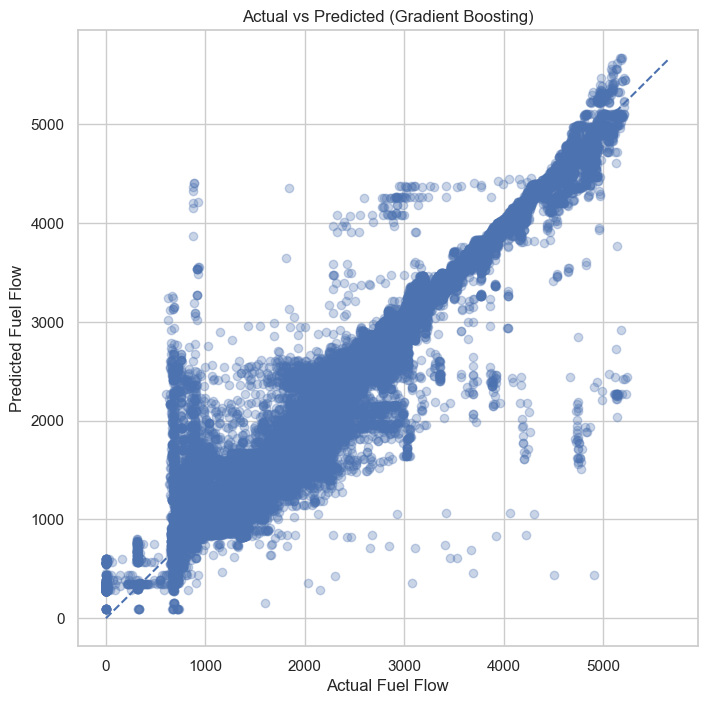

In [44]:
# ==========================================================
# ACTUAL VS PREDICTED
# ==========================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.3
)

mn = min(y_test.min(), best_pred.min())
mx = max(y_test.max(), best_pred.max())

plt.plot(
    [mn,mx],
    [mn,mx],
    linestyle="--"
)

plt.xlabel("Actual Fuel Flow")
plt.ylabel("Predicted Fuel Flow")

plt.title(
    f"Actual vs Predicted ({best_model_name})"
)

plt.show()

# Residual Analysis

Residual:

Actual − Predicted

A good model should have:

- Mean residual close to zero
- Symmetric distribution
- No obvious patterns

Residual analysis is one of the most important model validation tools.

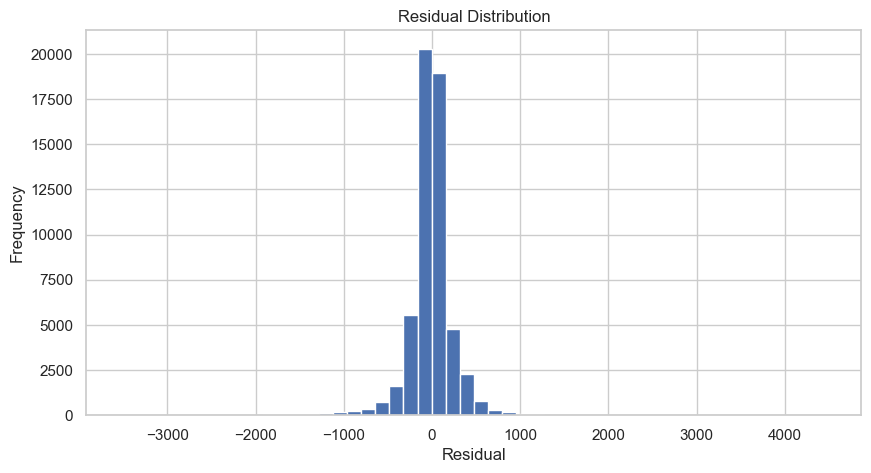

In [45]:
# ==========================================================
# RESIDUAL HISTOGRAM
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=50
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

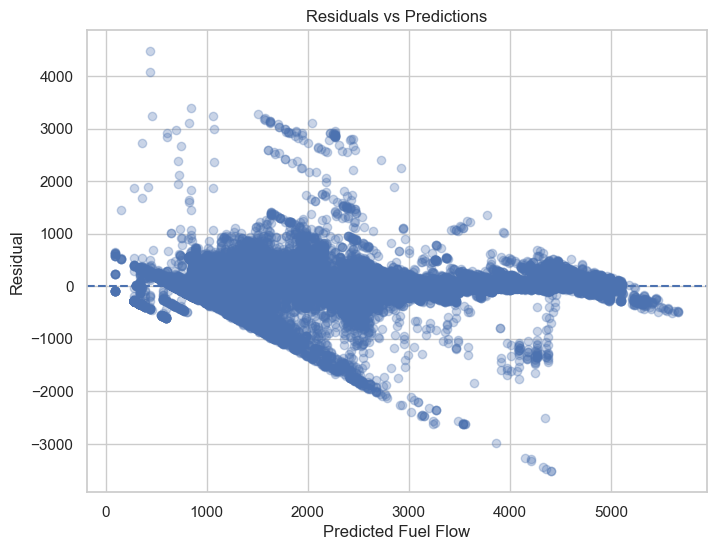

In [46]:
# ==========================================================
# RESIDUAL SCATTER
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    best_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Fuel Flow")
plt.ylabel("Residual")

plt.title("Residuals vs Predictions")

plt.show()

# Interpretation

Ideal pattern:

Random cloud around zero.

Bad signs:

- Funnel shape
- Curvature
- Strong clusters

These indicate model misspecification or missing features.

# Feature Importance

Understanding feature importance helps answer:

What actually drives fuel consumption?

This is often more valuable than prediction accuracy itself.

Airlines are interested in:

- Which variables matter most
- Which operational factors can be optimized

In [47]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

if hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({

        "Feature": FEATURES,

        "Importance":
        best_model.feature_importances_

    })

    importance_df = (
        importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
    )

    importance_df

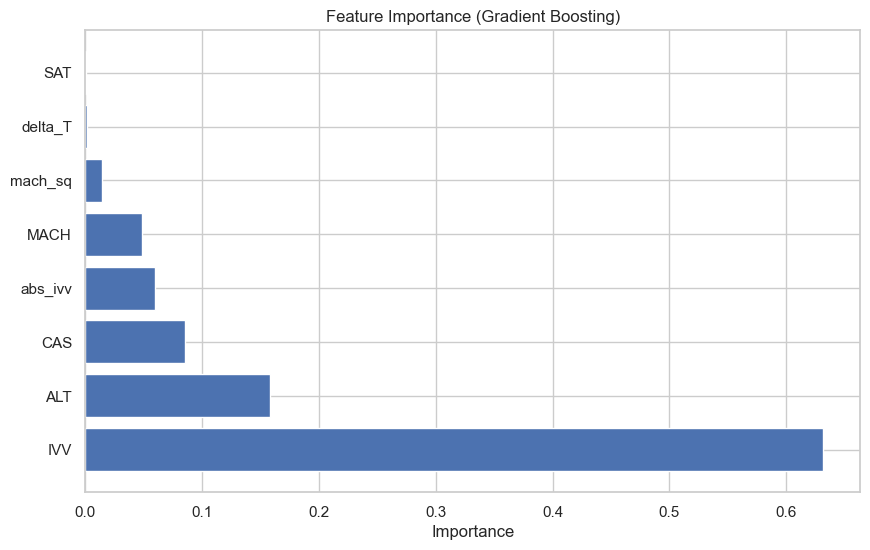

In [48]:
# ==========================================================
# FEATURE IMPORTANCE PLOT
# ==========================================================

if hasattr(best_model, "feature_importances_"):

    plt.figure(figsize=(10,6))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.title(
        f"Feature Importance ({best_model_name})"
    )

    plt.xlabel("Importance")

    plt.show()

# Aviation Interpretation

Expected high-importance variables:

### N1_avg

Engine thrust proxy.

Higher thrust requires higher fuel burn.

---

### Altitude

Aircraft performance changes with altitude.

---

### Mach

Speed directly influences aerodynamic drag.

---

### Delta Temperature

Atmospheric conditions affect engine efficiency.

---

### Vertical Velocity

Climb operations require additional energy.

In [49]:
# ==========================================================
# TOP FEATURES
# ==========================================================

if hasattr(best_model, "feature_importances_"):

    print("Top 10 Features")

    display(
        importance_df.head(10)
    )

Top 10 Features


,Feature,Importance
5,IVV,0.631667
0,ALT,0.157820
1,CAS,0.085300
6,abs_ivv,0.059816
2,MACH,0.048734
7,mach_sq,0.014285
4,delta_T,0.001603
3,SAT,0.000775


# Business Conclusions

This project demonstrates that aircraft fuel consumption can be predicted using flight recorder data.

Key findings:

1. Fuel flow is strongly related to engine power settings.
2. Aircraft speed significantly affects fuel burn.
3. Atmospheric conditions contribute to variability.
4. Machine learning models can capture complex nonlinear relationships.

The project illustrates how operational flight data can support fuel efficiency initiatives.

# Recommendations

For airline operators:

### Engine Management

Maintain efficient N1 settings whenever operationally feasible.

---

### Speed Optimization

Excessive speed increases fuel burn.

---

### Flight Planning

Account for atmospheric conditions when estimating fuel requirements.

---

### Monitoring

Use predictive fuel-flow models for real-time performance monitoring.

# Limitations

This project has several limitations.

1. **Gross Weight (GW) is unavailable** — weight is a key driver of fuel burn but is not in Tail_687.
2. **Wind information is not used** — headwind/tailwind significantly affects fuel consumption.
3. **Aircraft configuration variables are excluded** — flap position, spoiler state.
4. **Fuel flow varies across aircraft types** — model is specific to Tail_687 aircraft type.

---

### Fixes applied in this version

| Issue | Fix Applied |
|-------|-------------|
| False duplicates from slow sensors | Added `t_sec` timestamp in `load_single_flight()` |
| N1 leakage (FF ≈ f(N1²) is trivial) | Removed `N1_avg` and `n1_sq` from FEATURES |
| Temporal leakage in train/test split | Replaced random split with `GroupShuffleSplit` by `flight_id` |
| `FL` redundant with `ALT` | Removed `FL` from FEATURES |
| Duplicate FEATURES cell | Removed duplicate Cell 48 definition |

Future models could incorporate GW estimates, wind data, and additional operational variables.
